In [1]:
import functools
import warnings

import botocore
import boto3
from iterpop import iterpop as ip
import numpy as np
import pandas as pd
import pandas as pd
from pandas.util import hash_pandas_object
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from dishpylib.pyhelpers import fit_control_t_distns

warnings.filterwarnings("ignore")


In [2]:
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmyg876
interpreter: 3.10.12 (main, Nov  4 2025, 08:48:33) [GCC 11.4.0]
notebook name: 2025-12-09-bb-complexity
notebook path: /home/runner/work/oee4/oee4/binder/2025-12-09-bb-complexity.ipynb
revision: bdac574
timestamp: 2025-12-11T01:38:14Z00:00

IPython==7.16.1
packaging==25.0


In [4]:
teeplot_subdir = "2025-12-09-bb-complexity"


In [5]:
@functools.lru_cache
def get_control_t_distns( bucket, prefix, suffix, endeavor, stint ):

    if suffix == "-10min-frombbnopout":
        suffix = ""

    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    control_competitions, = bucket_handle.objects.filter(
        Prefix=f'endeavor={endeavor}/{prefix}control-competitions{suffix}/stage={2 + 2 * bool(prefix) + 2 * bool(suffix)}+what=collated/stint={stint}/',
    )

    control_df = pd.read_csv(
        f's3://{bucket}/{control_competitions.key}',
    )

    return fit_control_t_distns(control_df[
        control_df["Root ID"] == 1
    ].copy())


In [6]:
def preprocess_competition_fitnesses(competitions_df, control_fits_df):
    # preprocess data
    @functools.lru_cache
    def h0_fit(series):
        return ip.popsingleton(
            control_fits_df[control_fits_df["Series"] == series].to_dict(
                orient="records",
            )
        )

    competitions_df["p"] = competitions_df.apply(
        lambda row: scipy_stats.t.cdf(
            row["Fitness Differential"],
            h0_fit(row["genome series"])["Fit Degrees of Freedom"],
            loc=h0_fit(row["genome series"])["Fit Loc"],
            scale=h0_fit(row["genome series"])["Fit Scale"],
        ),
        axis=1,
    )
    competitions_df["Is Less Fit"] = competitions_df["p"] < 1.0 / 40
    competitions_df["Is More Fit"] = competitions_df["p"] > (1.0 -  1.0 / 40)
    competitions_df["Is Neutral"] = ~(
        competitions_df["Is Less Fit"] | competitions_df["Is More Fit"]
    )
    competitions_df["Relative Fitness"] = competitions_df.apply(
        lambda row: (
            "Significantly Advantageous"
            if row["Is More Fit"]
            else (
                "Significantly Deleterious" if row["Is Less Fit"] else "Neutral"
            )
        ),
        axis=1,
    )

    return competitions_df


# get data


In [7]:
bucket = "prq49"
dfs = []
prefix = ""
for suffix in [
    "-focalbb",
    "-10min-frombbnopout",
]:
    if "step" in bucket:
        step = int(bucket.split("-step")[-1]) + 1
    else:
        step = 0
    if "restint" in bucket:
        kind = bucket.split("-")[3]
    else:
        kind = None
    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    for stint in tqdm(range(1, 101)):
        try:
            series_profiles, = bucket_handle.objects.filter(
                Prefix=f'endeavor=16/{prefix}variant-competitions{suffix}/stage=4+what=collated/stint={stint}/',
            )
            import warnings
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
            control_fits_df = get_control_t_distns(
                bucket, prefix, suffix, 16, stint
            )
            df = pd.read_csv(
                f's3://{bucket}/{series_profiles.key}',
                compression='xz',
            )
            df = df[df["Competition Series"] == 16005]
            df = df.groupby("genome variation").mean(numeric_only=True).reset_index()
            df["Stint"] = stint
            dfdigest = "{:x}".format( hash_pandas_object( df ).sum() )
            df = preprocess_competition_fitnesses(df, control_fits_df)

            df = df.copy()
            df["bucket"] = bucket
            df["variant"] = {
                "-focalbb": "bb", "-10min-frombbnopout": "nobb"
            }[suffix]
            dfs.append(df)
        except Exception as e:
            print(e)
            print(f"Skipping {bucket=}, {stint=}, {prefix=}")


  0%|          | 0/100 [00:00<?, ?it/s]

not enough values to unpack (expected 1, got 0)
Skipping bucket='prq49', stint=1, prefix=''


  9%|▉         | 9/100 [00:02<00:28,  3.23it/s]

not enough values to unpack (expected 1, got 0)
Skipping bucket='prq49', stint=10, prefix=''


 83%|████████▎ | 83/100 [00:47<00:09,  1.77it/s]

not enough values to unpack (expected 1, got 0)
Skipping bucket='prq49', stint=84, prefix=''


100%|██████████| 100/100 [00:57<00:00,  1.73it/s]


In [8]:
df = pd.concat(dfs)


In [9]:
pd.options.display.max_columns = None


In [10]:
dfx = df[
    df["Root ID"] == 1
].groupby(["Stint", "bucket", "variant"]).agg(
    {
        "Is More Fit": "sum",
        "Is Less Fit": "sum",
        "Is Neutral": "sum",
        "genome variation": "count",
    },
)
dfx


Is More Fit  Is Less Fit  Is Neutral  genome variation
Stint bucket variant                                                        
1     prq49  bb                 3            8          34                45
2     prq49  bb                 3           24          42                69
             nobb               2           20          46                68
3     prq49  bb                 1           25          52                78
             nobb               2           14          61                77
...                           ...          ...         ...               ...
98    prq49  nobb               1           35         130               166
99    prq49  bb                 1           34         134               169
             nobb               0           37         131               168
100   prq49  bb                 1           46         119               166
             nobb               0           35         130               165

[197 rows x 4 columns]

In [11]:
dfx = dfx.reset_index(drop=False)


In [12]:
dfx["epoch"] = np.minimum(dfx["Stint"], 99) // 20


teeplots/2025-12-09-bb-complexity/hue=variant+marker=o+style=variant+viz=lineplot+x=stint+y=is-less-fit+ext=.pdf
teeplots/2025-12-09-bb-complexity/hue=variant+marker=o+style=variant+viz=lineplot+x=stint+y=is-less-fit+ext=.png


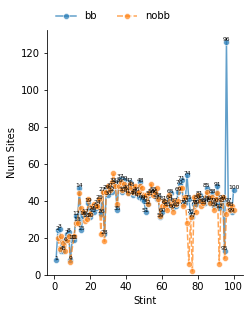

teeplots/2025-12-09-bb-complexity/hue=variant+marker=o+style=variant+viz=lineplot+x=stint+y=is-more-fit+ext=.pdf
teeplots/2025-12-09-bb-complexity/hue=variant+marker=o+style=variant+viz=lineplot+x=stint+y=is-more-fit+ext=.png


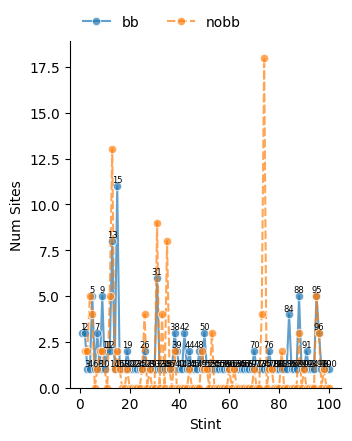

teeplots/2025-12-09-bb-complexity/hue=variant+marker=o+style=variant+viz=lineplot+x=stint+y=is-neutral+ext=.pdf
teeplots/2025-12-09-bb-complexity/hue=variant+marker=o+style=variant+viz=lineplot+x=stint+y=is-neutral+ext=.png


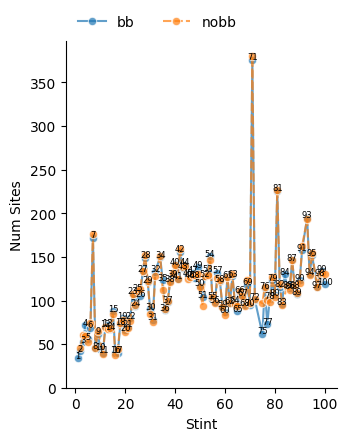

In [13]:
for y in ["Is Less Fit", "Is More Fit", "Is Neutral"]:
    data = dfx[
        dfx[y] < 500
    ]
    with tp.teed(
        sns.lineplot,
        data=data,
        x="Stint",
        y=y,
        alpha=0.7,
        hue="variant",
        marker="o",
        style="variant",
        teeplot_subdir=teeplot_subdir,
    ) as ax:
        ax.figure.set_size_inches(3.5, 4.5)
        ax.set_ylabel("Num Sites")
        sns.move_legend(
            ax,
            "lower left",
            bbox_to_anchor=(0, 1),
            title="",
            frameon=False,
            ncol=2,
        )
        sns.despine(ax=ax)
        ax.set_ylim(0, None)

        for x in range(101):
            try:
                ax.text(
                    x,
                    data[
                        (data["Stint"] == x)
                        & (data["variant"] == "bb")
                    ][y].values[0] + 0.2,
                    str(x),
                    color="black",
                    fontsize=6,
                    ha="center",
                )
            except IndexError:
                pass
        # ax.set_yscale("log")
